In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.graphics.mosaicplot import mosaic
heroes = pd.read_csv("heroes_clean.csv")

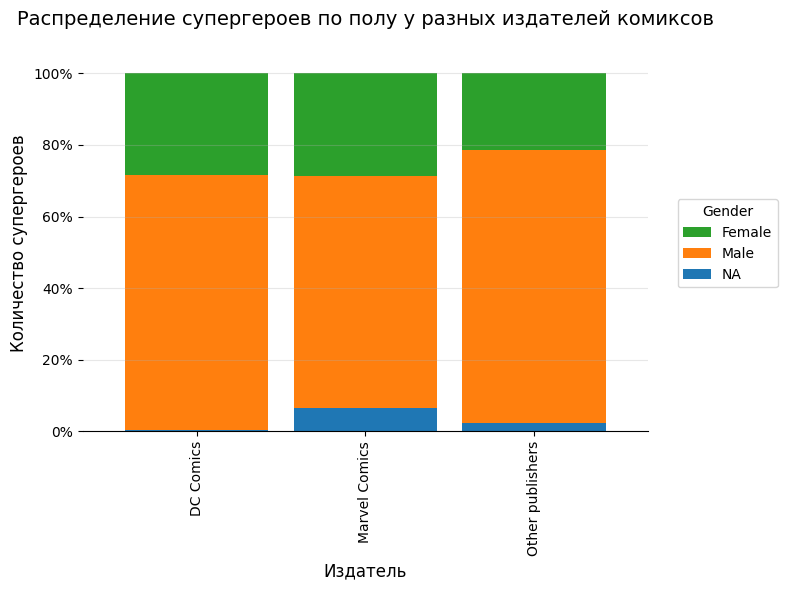

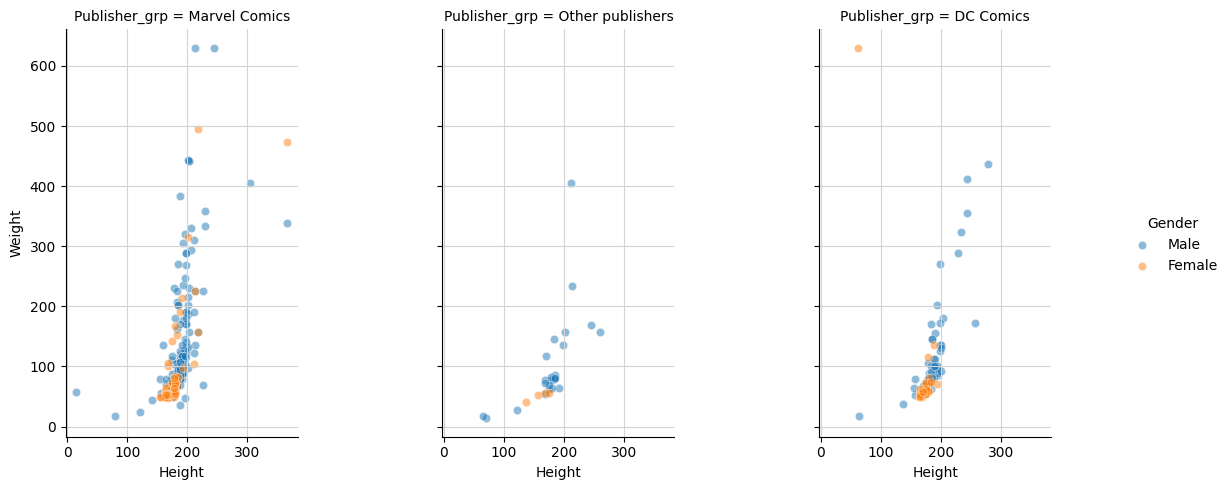

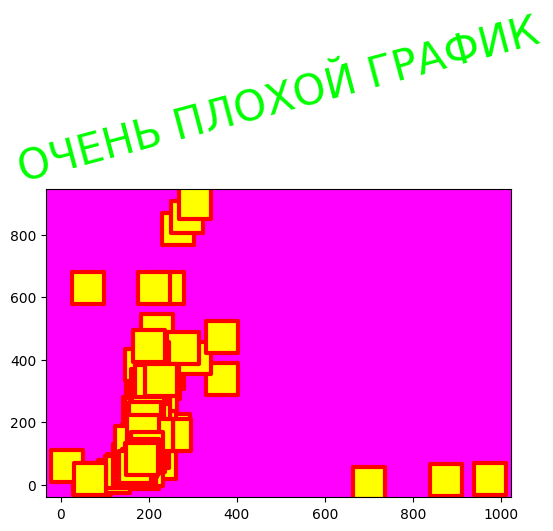

In [8]:
# Lab 25 Построение графиков 



heroes['Gender_filled'] = heroes['Gender'].fillna('NA')

ct = pd.crosstab(heroes['Publisher_grp'], heroes['Gender_filled'], normalize='index')

ct = ct[['NA', 'Male', 'Female']]

ax = ct.plot(kind='bar', stacked=True, figsize=(8, 6), width=0.85)

plt.title("Распределение супергероев по полу у разных издателей комиксов\n", fontsize=14)
plt.ylabel("Количество супергероев", fontsize=12)
plt.xlabel("Издатель", fontsize=12)

plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))

handles, labels = ax.get_legend_handles_labels()
plt.legend(handles[::-1], labels[::-1], title='Gender', bbox_to_anchor=(1.04, 0.5), loc='center left')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
plt.grid(axis='y', linestyle='-', alpha=0.3) 

plt.tight_layout()
plt.show()


filtered_heroes = heroes[(heroes['Weight'] < 700) & (heroes['Height'] < 400)]

g = sns.FacetGrid(filtered_heroes, col="Publisher_grp", hue="Gender", height=5, aspect=0.8)
g.map(sns.scatterplot, "Height", "Weight", alpha=0.5) # alpha отвечает за прозрачность
g.set_axis_labels("Height", "Weight")
g.add_legend(title="Gender")
for ax in g.axes.flat:
    ax.set_aspect('equal', 'box')
    ax.grid(True, linestyle='-', color='lightgrey')
plt.show()

plt.figure(figsize=(6, 4))
plt.scatter(heroes['Height'], heroes['Weight'], c='yellow', marker='s', s=500, edgecolors='red', linewidths=3)
plt.title("ОЧЕНЬ ПЛОХОЙ ГРАФИК", fontsize=30, color='lime', rotation=15)
plt.gca().set_facecolor('magenta')
plt.show()

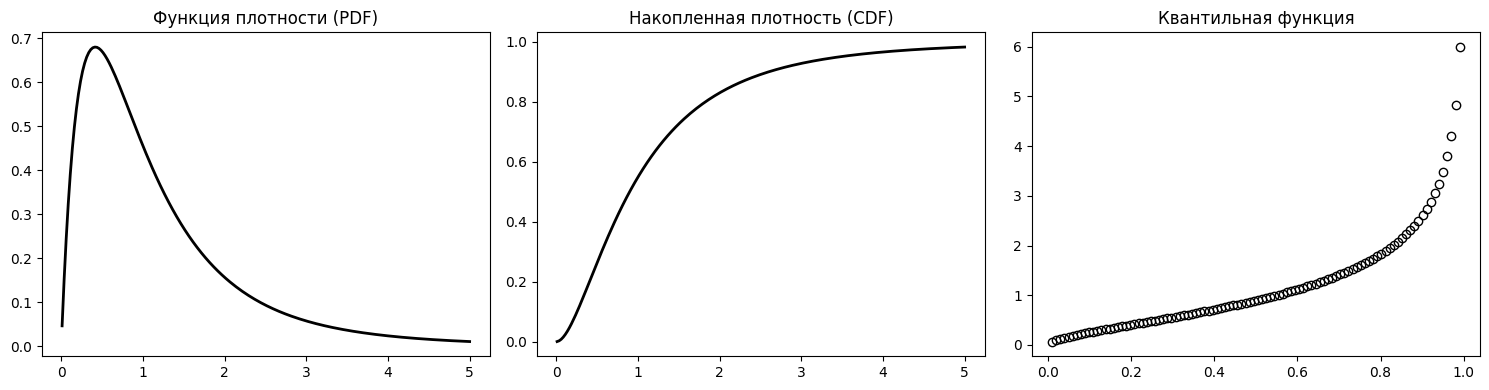

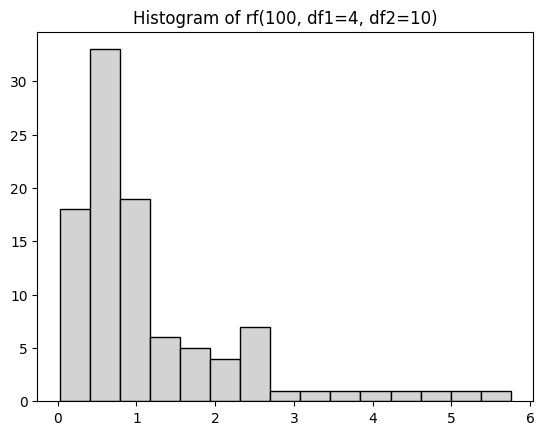

In [9]:
# Lab 26 Распределения



df1, df2 = 4, 10
x = np.linspace(0.01, 5, 200)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(x, stats.f.pdf(x, df1, df2), color='black', lw=2)
axes[0].set_title('Функция плотности (PDF)')

axes[1].plot(x, stats.f.cdf(x, df1, df2), color='black', lw=2)
axes[1].set_title('Накопленная плотность (CDF)')

p = np.linspace(0.01, 0.99, 100)
axes[2].plot(p, stats.f.ppf(p, df1, df2), 'o', markeredgecolor='black', markerfacecolor='none')
axes[2].set_title('Квантильная функция')

plt.tight_layout()
plt.show()

sample = stats.f.rvs(df1, df2, size=100)
plt.hist(sample, bins=15, edgecolor='black', color='lightgrey')
plt.title("Histogram of rf(100, df1=4, df2=10)")
plt.show()

In [15]:
# Lab 27 Одновыборочный t-test



weight = heroes['Weight'].dropna()
t_stat_w, p_val_w = stats.ttest_1samp(weight, 100)
print(f"T-test для веса (mu=100): t-stat = {t_stat_w:.3f}, p-value = {p_val_w:.3e}")

height = heroes['Height'].dropna()
t_stat_h, p_val_h = stats.ttest_1samp(height, 185)
print(f"T-test для роста (mu=185): t-stat = {t_stat_h:.3f}, p-value = {p_val_h:.3e}")
print(f"""
Результат: Средний вес в датасете около 112 кг. p-value получилось микроскопическим (намного меньше 0.05).
Интерпретация: Мы отвергаем нулевую гипотезу. Настоящий средний вес супергероев статистически значимо отличается от 100 кг.
Это не случайность выборки, супергерои действительно тяжелее.

Для роста (проверяем число 185 см):
Результат: Средний рост в датасете около 186.7 см. Разница с 185 вроде бы есть, но p-value получится больше 0.05.
Интерпретация: Мы НЕ можем отвергнуть нулевую гипотезу. Нет статистически значимых доказательств, что средний рост отличается от 185 см. 
Эта разница в 1.7 см легко объясняется обычным случайным разбросом в данных.""")

T-test для веса (mu=100): t-stat = 2.617, p-value = 9.133e-03
T-test для роста (mu=185): t-stat = 0.662, p-value = 5.080e-01

Результат: Средний вес в датасете около 112 кг. p-value получилось микроскопическим (намного меньше 0.05).
Интерпретация: Мы отвергаем нулевую гипотезу. Настоящий средний вес супергероев статистически значимо отличается от 100 кг.
Это не случайность выборки, супергерои действительно тяжелее.

Для роста (проверяем число 185 см):
Результат: Средний рост в датасете около 186.7 см. Разница с 185 вроде бы есть, но p-value получится больше 0.05.
Интерпретация: Мы НЕ можем отвергнуть нулевую гипотезу. Нет статистически значимых доказательств, что средний рост отличается от 185 см. 
Эта разница в 1.7 см легко объясняется обычным случайным разбросом в данных.



26.31 Хи-квадрат Пирсона

Доля женщин (is_human):
 is_human
0.0    0.240741
1.0    0.241546
Name: Gender, dtype: float64

Хи-квадрат (is_human vs Gender): p-value = 1.000


<Figure size 700x500 with 0 Axes>

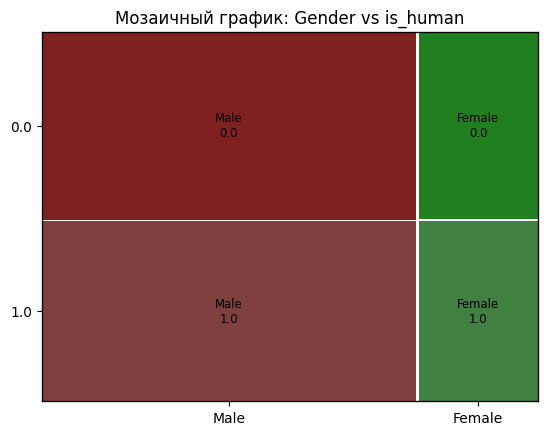

In [14]:
# Lab 31 Критерий хи-квадрат Пирсона



print("\n26.31 Хи-квадрат Пирсона\n")

heroes['is_human'] = np.where(heroes['Race'].isna(), np.nan, heroes['Race'] == 'Human')

human_gender_df = heroes.dropna(subset=['is_human', 'Gender'])

female_props = human_gender_df.groupby('is_human')['Gender'].apply(lambda x: (x == 'Female').mean())
print("Доля женщин (is_human):\n", female_props)

contingency_human_gender = pd.crosstab(human_gender_df['is_human'], human_gender_df['Gender'])
chi2_2, p_2, dof_2, expected_2 = stats.chi2_contingency(contingency_human_gender)
print(f"\nХи-квадрат (is_human vs Gender): p-value = {p_2:.3f}")

# 4. Мозаичный график
plt.figure(figsize=(7, 5))
mosaic(human_gender_df, ['Gender', 'is_human'], title='Мозаичный график: Gender vs is_human')
plt.show()